# EXP-005 — SeqBoostNet
Two-level stacking ensemble: **LSTM + XGBoost + GradientBoosting → AdaBoost**.
Input: 19-feature FFT+UMAP matrix from EXP-002.

Architecture (paper §3.6):
- **Level 0** — three base models trained independently; 3-fold OOF predictions form meta-features
- **Level 1** — AdaBoost meta-model trained on stacked OOF probabilities (12 columns: 4 classes × 3 models)
- Final base models re-trained on full training set for inference

In [1]:
import sys, os
sys.path.insert(0, str(__import__('pathlib').Path('..').resolve()))
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import keras
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping

from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)

from src.beed.config import CLASS_LABELS, DATA_PROCESSED, FIGURES, RANDOM_STATE

FIGURES.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
sns.set_theme(style='whitegrid')
print(f'Keras {keras.__version__}  |  XGBoost ready')

Keras 3.14.1  |  XGBoost ready


## 1. Load 19-feature matrices (from EXP-002)

In [2]:
train_df = pd.read_parquet(DATA_PROCESSED / 'train_features.parquet')
val_df   = pd.read_parquet(DATA_PROCESSED / 'val_features.parquet')
test_df  = pd.read_parquet(DATA_PROCESSED / 'test_features.parquet')

feature_cols = [c for c in train_df.columns if c != 'y']

X_train = train_df[feature_cols].values.astype(np.float32)
y_train = train_df['y'].values
X_val   = val_df[feature_cols].values.astype(np.float32)
y_val   = val_df['y'].values
X_test  = test_df[feature_cols].values.astype(np.float32)
y_test  = test_df['y'].values

print(f'Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}')
print(f'Features: {feature_cols}')

# LSTM expects 3-D input: (samples, timesteps, features)
# Treat each of the 19 features as a sequential timestep
X_train_3d = X_train.reshape(-1, X_train.shape[1], 1)
X_val_3d   = X_val.reshape(-1, X_val.shape[1], 1)
X_test_3d  = X_test.reshape(-1, X_test.shape[1], 1)
print(f'LSTM input shape: {X_train_3d.shape}')

Train: (5600, 19)  Val: (800, 19)  Test: (1600, 19)
Features: ['Fp1_fft', 'Fp2_fft', 'F3_fft', 'F4_fft', 'C3_fft', 'C4_fft', 'P3_fft', 'P4_fft', 'O1_fft', 'O2_fft', 'F7_fft', 'F8_fft', 'T3_fft', 'T4_fft', 'T5_fft', 'T6_fft', 'umap_1', 'umap_2', 'umap_3']
LSTM input shape: (5600, 19, 1)


## 2. Model builders
Hyperparameters from paper §3.6.5.

In [3]:
N_CLASSES   = 4
N_FEATURES  = X_train.shape[1]   # 19
N_FOLDS     = 3


def build_lstm(n_features: int = N_FEATURES, n_classes: int = N_CLASSES) -> keras.Model:
    model = Sequential([
        LSTM(128, activation='relu', input_shape=(n_features, 1)),
        Dropout(0.5),
        Dense(n_classes, activation='softmax'),
    ])
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model


def build_xgb() -> XGBClassifier:
    return XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        objective='multi:softmax',
        num_class=N_CLASSES,
        use_label_encoder=False,
        eval_metric='mlogloss',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )


def build_gb() -> GradientBoostingClassifier:
    return GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=RANDOM_STATE,
    )


print('Model builders defined.')
print(f'Meta-features per sample: {N_CLASSES * 3} (4 classes × 3 base models)')

Model builders defined.
Meta-features per sample: 12 (4 classes × 3 base models)


## 3. Out-of-fold stacking (Level 0)
3-fold stratified CV: each fold trains the three base models and records their
probability predictions on the held-out fold. These OOF predictions become the
meta-features for training AdaBoost.

In [4]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

# Pre-allocate meta-feature matrix: (n_train, 12)  — 4 probs × 3 models
meta_train = np.zeros((len(X_train), N_CLASSES * 3), dtype=np.float32)

early_stop = EarlyStopping(
    monitor='val_loss', patience=8, restore_best_weights=True, verbose=0
)

for fold_idx, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    print(f'\n=== Fold {fold_idx + 1}/{N_FOLDS} ===')

    Xf_tr,  Xf_val  = X_train[tr_idx],    X_train[val_idx]
    Xf_tr3, Xf_val3 = X_train_3d[tr_idx], X_train_3d[val_idx]
    yf_tr,  yf_val  = y_train[tr_idx],    y_train[val_idx]

    # --- LSTM ---
    keras.utils.set_random_seed(RANDOM_STATE + fold_idx)
    lstm = build_lstm()
    lstm.fit(
        Xf_tr3, yf_tr,
        validation_data=(Xf_val3, yf_val),
        epochs=50, batch_size=32,
        callbacks=[early_stop], verbose=0,
    )
    meta_train[val_idx, :N_CLASSES] = lstm.predict(Xf_val3, verbose=0)
    print(f'  LSTM stopped at epoch {early_stop.stopped_epoch or 50}')

    # --- XGBoost ---
    xgb = build_xgb()
    xgb.fit(Xf_tr, yf_tr, eval_set=[(Xf_val, yf_val)], verbose=False)
    meta_train[val_idx, N_CLASSES:N_CLASSES*2] = xgb.predict_proba(Xf_val)
    print(f'  XGBoost done.')

    # --- GradientBoosting ---
    gb = build_gb()
    gb.fit(Xf_tr, yf_tr)
    meta_train[val_idx, N_CLASSES*2:] = gb.predict_proba(Xf_val)
    print(f'  GradientBoosting done.')

    del lstm
    keras.backend.clear_session()

print('\nOOF predictions complete.')
print(f'meta_train shape: {meta_train.shape}')


=== Fold 1/3 ===


C:\dev\BEED\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  LSTM stopped at epoch 50


C:\dev\BEED\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [02:29:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  XGBoost done.


...

C:\dev\BEED\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  LSTM stopped at epoch 7


C:\dev\BEED\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [02:30:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  XGBoost done.


  GradientBoosting done.

OOF predictions complete.
meta_train shape: (5600, 12)


## 4. Train AdaBoost meta-model (Level 1)

In [5]:
ada = AdaBoostClassifier(
    n_estimators=50,
    learning_rate=1.0,
    random_state=RANDOM_STATE,
)
ada.fit(meta_train, y_train)
print('AdaBoost meta-model trained on OOF predictions.')
print(f'Meta-feature columns: {meta_train.shape[1]}')

AdaBoost meta-model trained on OOF predictions.
Meta-feature columns: 12


## 5. Retrain base models on full training set

In [6]:
print('Retraining LSTM on full training set (100 epochs)...')
keras.utils.set_random_seed(RANDOM_STATE)
final_lstm = build_lstm()
final_early = EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True, verbose=0
)
final_lstm.fit(
    X_train_3d, y_train,
    validation_data=(X_val_3d, y_val),
    epochs=100, batch_size=32,
    callbacks=[final_early], verbose=0,
)
print(f'  LSTM stopped at epoch {final_early.stopped_epoch or 100}')

print('Retraining XGBoost on full training set...')
final_xgb = build_xgb()
final_xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
print('  XGBoost done.')

print('Retraining GradientBoosting on full training set...')
final_gb = build_gb()
final_gb.fit(X_train, y_train)
print('  GradientBoosting done.')

Retraining LSTM on full training set (100 epochs)...


C:\dev\BEED\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  LSTM stopped at epoch 83
Retraining XGBoost on full training set...


C:\dev\BEED\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [02:34:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  XGBoost done.
Retraining GradientBoosting on full training set...


  GradientBoosting done.


## 6. Inference helper

In [7]:
def seqboostnet_predict(X_2d: np.ndarray, X_3d: np.ndarray) -> np.ndarray:
    """Stack base-model proba predictions and pass through AdaBoost."""
    p_lstm = final_lstm.predict(X_3d, verbose=0)
    p_xgb  = final_xgb.predict_proba(X_2d)
    p_gb   = final_gb.predict_proba(X_2d)
    meta   = np.hstack([p_lstm, p_xgb, p_gb])
    return ada.predict(meta)


print('seqboostnet_predict() ready.')

seqboostnet_predict() ready.


## 7. Evaluate on validation set

In [8]:
label_names = [CLASS_LABELS[i] for i in sorted(CLASS_LABELS)]

preds_val = seqboostnet_predict(X_val, X_val_3d)
print('=== SeqBoostNet — Validation ===')
print(classification_report(y_val, preds_val, target_names=label_names))

=== SeqBoostNet — Validation ===
                precision    recall  f1-score   support

       Healthy       1.00      0.95      0.97       200
         Focal       0.89      0.81      0.85       200
   Generalized       0.87      0.74      0.80       200
Seizure Events       0.69      0.89      0.78       200

      accuracy                           0.85       800
     macro avg       0.86      0.85      0.85       800
  weighted avg       0.86      0.85      0.85       800



## 8. Evaluate on test set

In [9]:
preds_test = seqboostnet_predict(X_test, X_test_3d)
print('=== SeqBoostNet — Test ===')
print(classification_report(y_test, preds_test, target_names=label_names))

=== SeqBoostNet — Test ===
                precision    recall  f1-score   support

       Healthy       1.00      0.98      0.99       400
         Focal       0.88      0.78      0.83       400
   Generalized       0.85      0.74      0.79       400
Seizure Events       0.69      0.87      0.77       400

      accuracy                           0.84      1600
     macro avg       0.86      0.84      0.85      1600
  weighted avg       0.86      0.84      0.85      1600



## 9. Confusion matrices

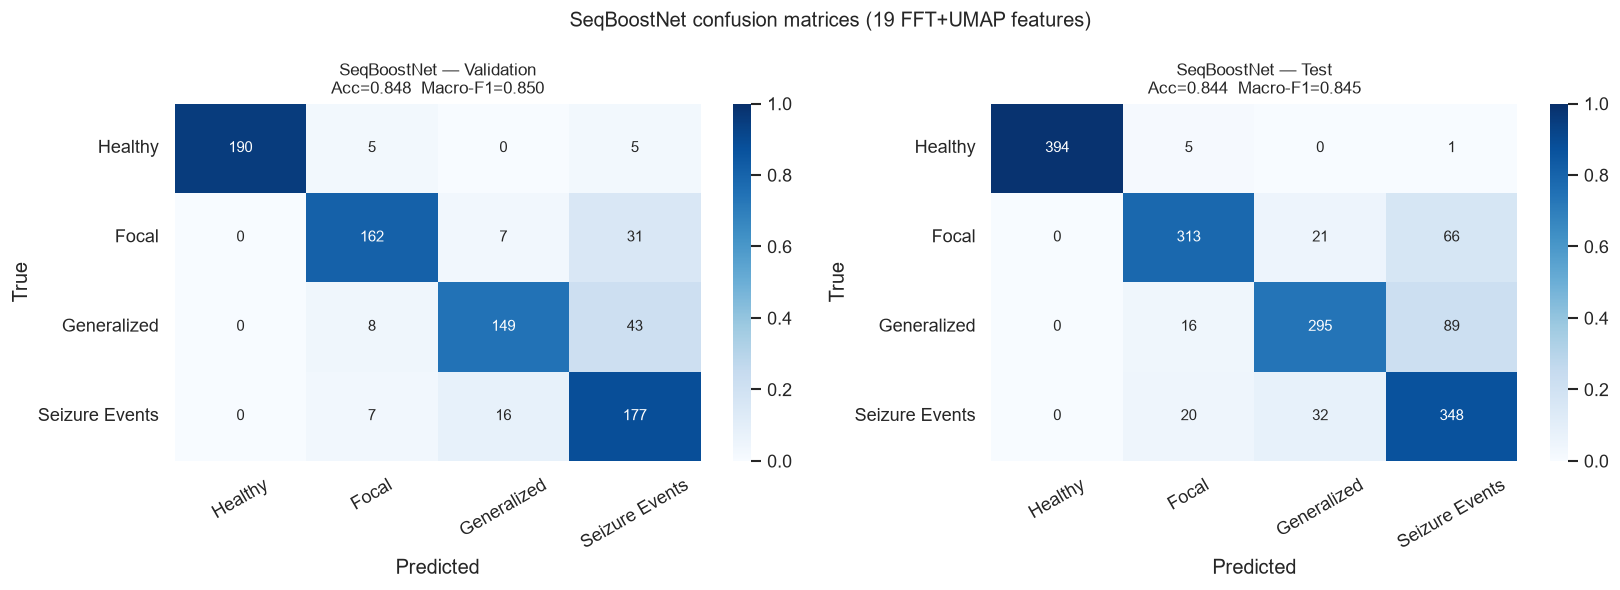

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (split_name, preds, y_true) in zip(
    axes,
    [('Validation', preds_val, y_val), ('Test', preds_test, y_test)]
):
    cm = confusion_matrix(y_true, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(
        cm_norm, annot=cm, fmt='d', ax=ax,
        xticklabels=label_names, yticklabels=label_names,
        cmap='Blues', vmin=0, vmax=1, annot_kws={'size': 9},
    )
    acc = accuracy_score(y_true, preds)
    f1  = f1_score(y_true, preds, average='macro')
    ax.set_title(f'SeqBoostNet — {split_name}\nAcc={acc:.3f}  Macro-F1={f1:.3f}', fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)

fig.suptitle('SeqBoostNet confusion matrices (19 FFT+UMAP features)', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES / '19_seqboostnet_confusion.png', bbox_inches='tight')
plt.show()

## 10. Base model breakdown

In [11]:
# Individual base model performance on test set
base_results = []
for name, preds_b in [
    ('LSTM',             final_lstm.predict(X_test_3d, verbose=0).argmax(axis=1)),
    ('XGBoost',          final_xgb.predict(X_test)),
    ('GradientBoosting', final_gb.predict(X_test)),
    ('SeqBoostNet',      preds_test),
]:
    base_results.append({
        'model': name,
        'accuracy': round(accuracy_score(y_test, preds_b), 4),
        'macro_f1': round(f1_score(y_test, preds_b, average='macro'), 4),
    })

base_df = pd.DataFrame(base_results)
print('Base model test performance:')
print(base_df.to_string(index=False))

Base model test performance:
           model  accuracy  macro_f1
            LSTM    0.7987    0.7957
         XGBoost    0.8725    0.8723
GradientBoosting    0.8131    0.8128
     SeqBoostNet    0.8438    0.8453


## 11. Progressive comparison: EXP-003 → EXP-004 → EXP-005

Experiment progression (test macro-F1):
              model  macro_f1                    exp
Logistic Regression    0.4678      EXP-003\n(raw 16)
      Random Forest    0.9538      EXP-003\n(raw 16)
Logistic Regression    0.7001 EXP-004\n(FFT+UMAP 19)
      Random Forest    0.8850 EXP-004\n(FFT+UMAP 19)
        SeqBoostNet    0.8453 EXP-005\n(SeqBoostNet)


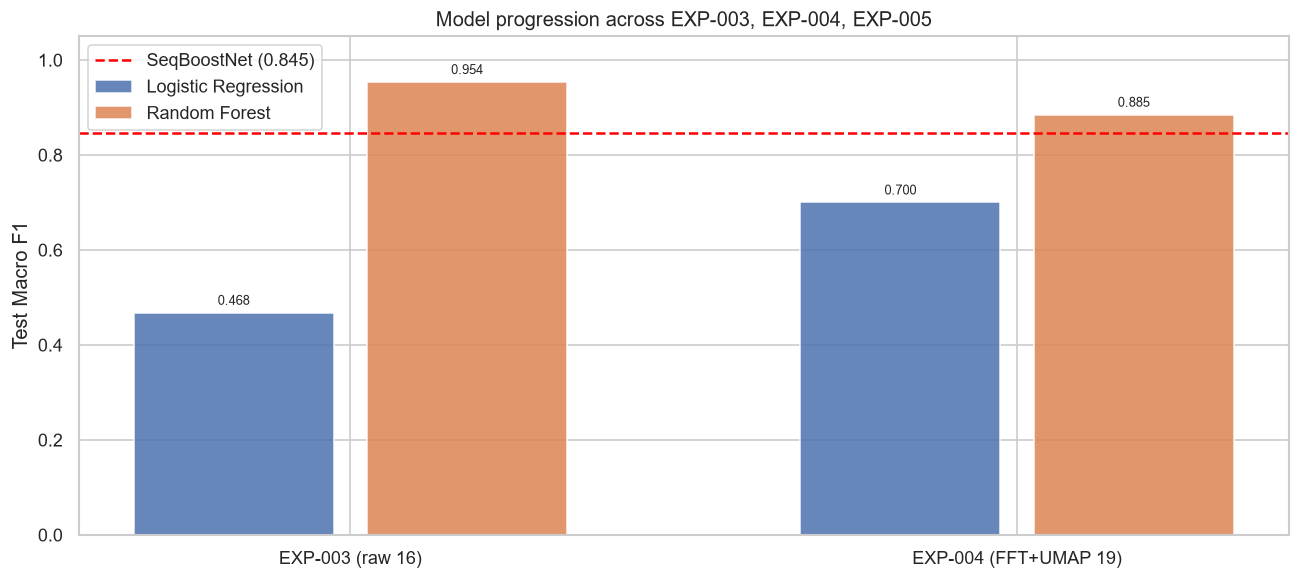

In [12]:
r3 = pd.read_csv(DATA_PROCESSED / 'exp003_baseline_results.csv')
r4 = pd.read_csv(DATA_PROCESSED / 'exp004_results.csv')

comp = pd.concat([
    r3[r3['split']=='test'][['model','macro_f1']].assign(exp='EXP-003\n(raw 16)'),
    r4[r4['split']=='test'][['model','macro_f1']].assign(exp='EXP-004\n(FFT+UMAP 19)'),
], ignore_index=True)

# Add SeqBoostNet row
comp = pd.concat([
    comp,
    pd.DataFrame([{
        'model': 'SeqBoostNet',
        'macro_f1': round(f1_score(y_test, preds_test, average='macro'), 4),
        'exp': 'EXP-005\n(SeqBoostNet)',
    }])
], ignore_index=True)

print('Experiment progression (test macro-F1):')
print(comp.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(11, 5))
pivot = comp[comp['model'].isin(['Logistic Regression', 'Random Forest'])].copy()
for i, model in enumerate(['Logistic Regression', 'Random Forest']):
    sub = pivot[pivot['model'] == model]
    x = [0 + i*0.35, 1 + i*0.35]
    ax.bar([0 + i*0.35, 1 + i*0.35], sub['macro_f1'].values,
           width=0.3, label=model, alpha=0.85)

seq_f1 = comp[comp['model'] == 'SeqBoostNet']['macro_f1'].values[0]
ax.axhline(seq_f1, color='red', linestyle='--', linewidth=1.5, label=f'SeqBoostNet ({seq_f1:.3f})')
ax.set_xticks([0.175, 1.175])
ax.set_xticklabels(['EXP-003 (raw 16)', 'EXP-004 (FFT+UMAP 19)'])
ax.set_ylim(0, 1.05)
ax.set_ylabel('Test Macro F1')
ax.set_title('Model progression across EXP-003, EXP-004, EXP-005')
ax.legend()
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES / '20_exp_progression.png', bbox_inches='tight')
plt.show()

## 12. Save results

In [13]:
rows = []
for split_name, preds_s, y_s in [('val', preds_val, y_val), ('test', preds_test, y_test)]:
    rows.append({
        'model': 'SeqBoostNet',
        'split': split_name,
        'accuracy': round(accuracy_score(y_s, preds_s), 4),
        'macro_f1': round(f1_score(y_s, preds_s, average='macro'), 4),
        'weighted_f1': round(f1_score(y_s, preds_s, average='weighted'), 4),
    })

results_005 = pd.DataFrame(rows)
results_005.to_csv(DATA_PROCESSED / 'exp005_seqboostnet_results.csv', index=False)
print('Saved exp005_seqboostnet_results.csv')
print(results_005.to_string(index=False))

Saved exp005_seqboostnet_results.csv
      model split  accuracy  macro_f1  weighted_f1
SeqBoostNet   val    0.8475    0.8500       0.8500
SeqBoostNet  test    0.8438    0.8453       0.8453


## 13. Summary

In [14]:
test_acc = accuracy_score(y_test, preds_test)
test_f1  = f1_score(y_test, preds_test, average='macro')

rf_raw_f1   = r3[(r3['model']=='Random Forest') & (r3['split']=='test')]['macro_f1'].values[0]
rf_fft_f1   = r4[(r4['model']=='Random Forest') & (r4['split']=='test')]['macro_f1'].values[0]
paper_avg   = 0.9671  # paper reports 96.71% average across A1-A6 binary cases

print('=== EXP-005 Summary ===')
print(f'Architecture  : LSTM(128) + XGB(300) + GB(100) → AdaBoost(50), 3-fold OOF stacking')
print(f'Feature set   : 19-feature FFT+UMAP matrix')
print()
print(f'SeqBoostNet test accuracy : {test_acc:.4f}')
print(f'SeqBoostNet test macro-F1 : {test_f1:.4f}')
print()
print(f'Reference baselines (test macro-F1):')
print(f'  RF on raw 16 features   : {rf_raw_f1:.4f}')
print(f'  RF on FFT+UMAP 19       : {rf_fft_f1:.4f}')
print()
print(f'Paper reported avg accuracy (A1-A6, binary): {paper_avg*100:.2f}%')
print(f'Note: paper reports binary cases; our result is 4-class multiclass.')

=== EXP-005 Summary ===
Architecture  : LSTM(128) + XGB(300) + GB(100) → AdaBoost(50), 3-fold OOF stacking
Feature set   : 19-feature FFT+UMAP matrix

SeqBoostNet test accuracy : 0.8438
SeqBoostNet test macro-F1 : 0.8453

Reference baselines (test macro-F1):
  RF on raw 16 features   : 0.9538
  RF on FFT+UMAP 19       : 0.8850

Paper reported avg accuracy (A1-A6, binary): 96.71%
Note: paper reports binary cases; our result is 4-class multiclass.
